# EDA Comparativo y Verificación de Calidad del Preprocesamiento de EmoEvent

**TFG — Chatbot de apoyo emocional para ciberacoso adolescente (UMU)**

Este notebook verifica la calidad del pipeline de preprocesamiento aplicado al dataset EmoEvent:
- Normalización de texto (eliminación de HASHTAG/USER/URL, conversión de emojis)
- Traducción ES→EN de clases minoritarias (fear, disgust, surprise)
- Generación de datos sintéticos para balanceo de clases
- Splits train/val/test sin data leakage

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_ROOT = Path('../data')
RAW_ES   = DATA_ROOT / 'raw/emoevent/emoevent_es.csv'
RAW_EN   = DATA_ROOT / 'raw/emoevent/emoevent_en.csv'
PREP_CSV = DATA_ROOT / 'processed/emoevent_preprocessed.csv'
SYNT_CSV = DATA_ROOT / 'processed/emoevent_preprocessed_synthetic.csv'
NS_DIR   = DATA_ROOT / 'processed/no_synthetic'
WS_DIR   = DATA_ROOT / 'processed/with_synthetic'

# Paleta de emociones
EMOTIONS = ['joy', 'others', 'sadness', 'disgust', 'anger', 'surprise', 'fear']
EMO_PALETTE = dict(zip(EMOTIONS, sns.color_palette('muted', len(EMOTIONS))))
print('Entorno listo.')

Entorno listo.


In [39]:
# --- Carga de datos ---
raw_es   = pd.read_csv(RAW_ES, sep='\t')
raw_en   = pd.read_csv(RAW_EN, sep='\t')
prep     = pd.read_csv(PREP_CSV)
synt_full = pd.read_csv(SYNT_CSV)

ns_train = pd.read_csv(NS_DIR / 'emoevent_train.csv')
ns_val   = pd.read_csv(NS_DIR / 'emoevent_val.csv')
ns_test  = pd.read_csv(NS_DIR / 'emoevent_test.csv')

ws_train = pd.read_csv(WS_DIR / 'emoevent_train.csv')
ws_val   = pd.read_csv(WS_DIR / 'emoevent_val.csv')
ws_test  = pd.read_csv(WS_DIR / 'emoevent_test.csv')

print(f'raw_es:    {raw_es.shape}')
print(f'raw_en:    {raw_en.shape}')
print(f'prep:      {prep.shape}')
print(f'synt_full: {synt_full.shape}')
print(f'ns  train/val/test: {ns_train.shape} / {ns_val.shape} / {ns_test.shape}')
print(f'ws  train/val/test: {ws_train.shape} / {ws_val.shape} / {ws_test.shape}')

raw_es:    (8409, 4)
raw_en:    (7303, 4)
prep:      (7231, 5)
synt_full: (7321, 5)
ns  train/val/test: (5061, 5) / (1085, 5) / (1085, 5)
ws  train/val/test: (5151, 5) / (1085, 5) / (1085, 5)


---
## Sección 1 — Comparativa de Distribución de Clases

In [40]:
# Conteos y ratios de desequilibrio
def imbalance_table(df: pd.DataFrame, label: str) -> pd.DataFrame:
    counts = df['emotion'].value_counts().reindex(EMOTIONS, fill_value=0)
    total = counts.sum()
    pct = (counts / total * 100).round(2)
    ratio = (counts.max() / counts).round(2)
    return pd.DataFrame({'emoción': EMOTIONS,
                         f'n_{label}': counts.values,
                         f'%_{label}': pct.values,
                         f'ratio_{label}': ratio.values}).set_index('emoción')

tbl_ns = imbalance_table(ns_train, 'sin_sint')
tbl_ws = imbalance_table(ws_train, 'con_sint')
tbl_comp = pd.concat([tbl_ns, tbl_ws], axis=1)

print('=== Tabla comparativa train (sin vs con sintéticos) ===')
display(tbl_comp.style
        .format({'%_sin_sint': '{:.2f}%', '%_con_sint': '{:.2f}%'})
        .background_gradient(cmap='Blues', subset=[c for c in tbl_comp.columns if c.startswith('n_')])
        .set_caption('Distribución de clases en split train'))

=== Tabla comparativa train (sin vs con sintéticos) ===


,n_sin_sint,%_sin_sint,ratio_sin_sint,n_con_sint,%_con_sint,ratio_con_sint
emoción,,,,,,
joy,1270,25.09%,1.000000,1270,24.66%,1.000000
others,1260,24.90%,1.010000,1260,24.46%,1.010000
sadness,706,13.95%,1.800000,706,13.71%,1.800000
disgust,648,12.80%,1.960000,688,13.36%,1.850000
anger,599,11.84%,2.120000,599,11.63%,2.120000
surprise,405,8.00%,3.140000,405,7.86%,3.140000
fear,173,3.42%,7.340000,223,4.33%,5.700000


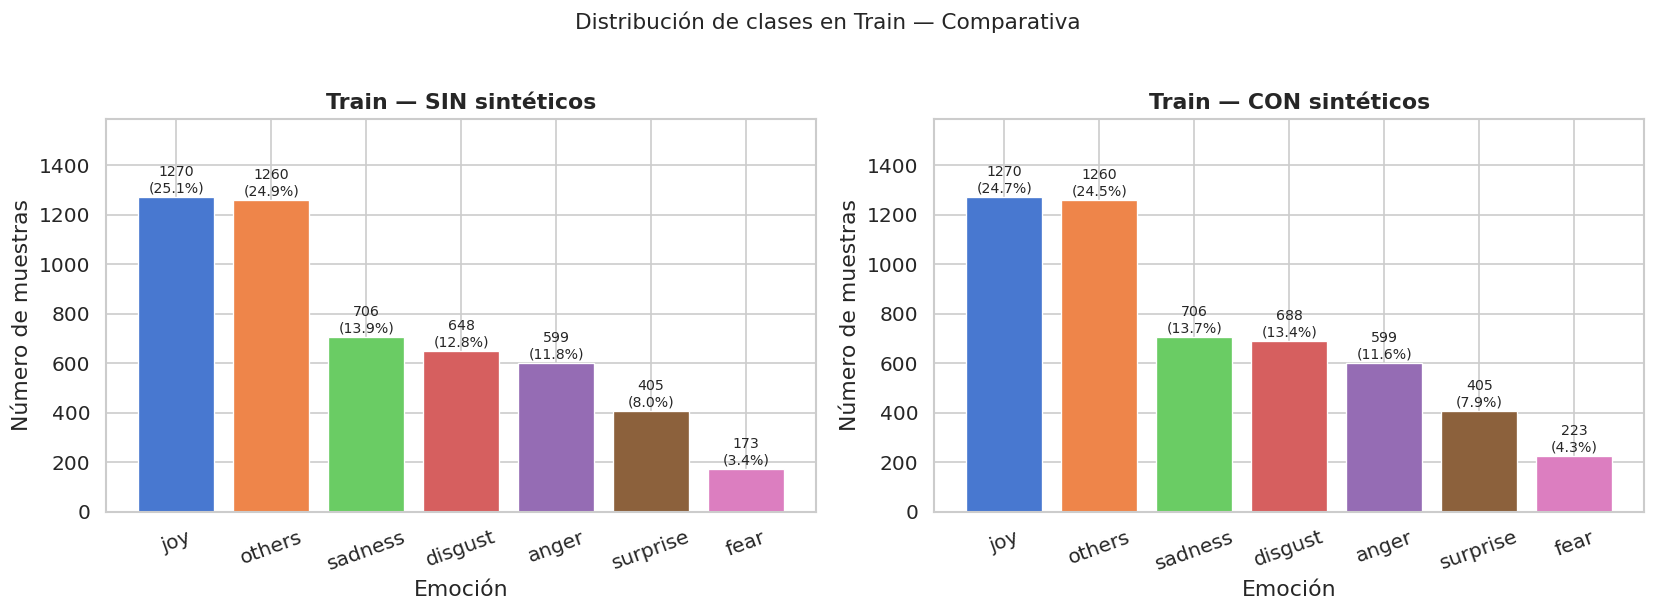

In [41]:
# Barplot lado a lado con porcentajes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, df, title in zip(axes,
                          [ns_train, ws_train],
                          ['Train — SIN sintéticos', 'Train — CON sintéticos']):
    counts = df['emotion'].value_counts().reindex(EMOTIONS, fill_value=0)
    total = counts.sum()
    colors = [EMO_PALETTE[e] for e in EMOTIONS]
    bars = ax.bar(EMOTIONS, counts.values, color=colors, edgecolor='white', linewidth=0.8)
    for bar, n in zip(bars, counts.values):
        pct = n / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 8,
                f'{n}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=8.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Emoción')
    ax.set_ylabel('Número de muestras')
    ax.set_ylim(0, counts.max() * 1.25)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Distribución de clases en Train — Comparativa', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DATA_ROOT / 'figures/train_class_comparison.png', bbox_inches='tight')
plt.show()

In [42]:
# Conclusión cuantitativa
ratio_ns = ns_train['emotion'].value_counts().max() / ns_train['emotion'].value_counts().min()
ratio_ws = ws_train['emotion'].value_counts().max() / ws_train['emotion'].value_counts().min()

print(f'Ratio max/min SIN sintéticos : {ratio_ns:.2f}x')
print(f'Ratio max/min CON sintéticos : {ratio_ws:.2f}x')
print(f'Mejora del ratio             : {ratio_ns / ratio_ws:.2f}x  ({(1 - ratio_ws/ratio_ns)*100:.1f}% reducción)')

Ratio max/min SIN sintéticos : 7.34x
Ratio max/min CON sintéticos : 5.70x
Mejora del ratio             : 1.29x  (22.4% reducción)


**Conclusión (Sección 1):** Los datos sintéticos reducen algo el ratio de desequilibrio entre la clase mayoritaria y la minoritaria al aumentar los datos de la clase fear y disgust, pero no de forma significativa.

---
## Sección 2 — Verificación de Normalización

In [43]:
# 10 muestras aleatorias: original vs preprocesado
# Usamos el id para hacer el match entre raw_es y prep (fuente original)
prep_orig = prep[prep['source'] == 'original'].copy()
raw_es_indexed = raw_es.set_index('id')

sample_ids = prep_orig['id'].sample(10, random_state=42).values

rows = []
for sid in sample_ids:
    raw_text = raw_es_indexed.loc[sid, 'tweet'] if sid in raw_es_indexed.index else '—'
    clean_text = prep_orig.loc[prep_orig['id'] == sid, 'text'].values[0]
    rows.append({'id': sid, 'texto_original': raw_text, 'texto_limpio': clean_text})

df_compare = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 120)
display(df_compare[['id', 'texto_original', 'texto_limpio']])

,id,texto_original,texto_limpio
0,835,"Respecto a la situación política de HASHTAG: pasamos de lo sublime a primera hora de la mañana, a la opacidad de la ...","Respecto a la situación política de : pasamos de lo sublime a primera hora de la mañana, a la opacidad de la informa..."
1,4744,"“Con Rivera no” dicen por Ferraz. Pues nada, con independentistas extremistas, que nos va a ir a todos mucho mejor.....","“Con Rivera no” dicen por Ferraz. Pues nada, con independentistas extremistas, que nos va a ir a todos mucho mejor....."
2,4159,Mk ese ida de la semi HASHTAG esta re bueno pana!!,Mk ese ida de la semi esta re bueno pana!!
3,1041,Militares Venezolanos a favor del Presidente de HASHTAG USER. URL,Militares Venezolanos a favor del Presidente de .
4,6341,🔥 El HASHTAG ha conquistado 8 de las últimas 11 ediciones de HASHTAG 🔥 HASHTAG HASHTAG URL,fuego El ha conquistado 8 de las últimas 11 ediciones de fuego
5,1009,"HASHTAG USER: ""El momento es ahora, no solo de la calma sino del coraje y la cordura"" URL",": ""El momento es ahora, no solo de la calma sino del coraje y la cordura"""
6,5432,"Pequeños gestos que puedes hacer por el medio ambiente: URL HASHTAG, mira con qué te vistes, come como tu abuela qu...","Pequeños gestos que puedes hacer por el medio ambiente: , mira con qué te vistes, come como tu abuela querría que lo..."
7,5647,Totalmente de acuerdo! Esperemos volver a verla así!! HASHTAG URL,Totalmente de acuerdo! Esperemos volver a verla así!!
8,2828,¡Conéctate ya a nuestro HASHTAG desde el USER! Feliz día del HASHTAG 👉 URL HASHTAG HASHTAG URL,¡Conéctate ya a nuestro desde el ! Feliz día del dorso de mano con índice a la derecha
9,6543,Posiblemente la victoria más exagerada del Barcelona en muchísimos años. No hubo tal diferencia en el campo HASHTAG,Posiblemente la victoria más exagerada del Barcelona en muchísimos años. No hubo tal diferencia en el campo


In [44]:
# Verificación: no quedan HASHTAG, USER, URL en el dataset preprocesado
tokens_to_check = ['HASHTAG', 'USER', 'URL']

print('=== Ocurrencias de tokens especiales en emoevent_preprocessed.csv ===')
for token in tokens_to_check:
    n = prep['text'].str.contains(token, regex=False).sum()
    status = '✓ OK (0)' if n == 0 else f'✗ ENCONTRADO ({n} filas)'
    print(f'  {token:10s}: {status}')

=== Ocurrencias de tokens especiales en emoevent_preprocessed.csv ===
  HASHTAG   : ✓ OK (0)
  USER      : ✓ OK (0)
  URL       : ✓ OK (0)


In [45]:
# Verificación: emojis convertidos a texto descriptivo
# Usamos re.search directamente (pandas str.contains con \U no es compatible con pyarrow)
EMOJI_PATTERN = re.compile(
    '[\U0001F300-\U0001F9FF\U00002600-\U000027BF\U0001FA00-\U0001FA9F]'
)

raw_es_with_emoji = raw_es[raw_es['tweet'].apply(lambda t: bool(EMOJI_PATTERN.search(str(t))))].copy()
ids_with_emoji = set(raw_es_with_emoji['id'].values)

prep_orig_emoji = prep_orig[prep_orig['id'].isin(ids_with_emoji)]

print(f'Tweets originales con emoji: {len(raw_es_with_emoji)}')
print(f'De estos, presentes en prep (originales): {len(prep_orig_emoji)}')
print()

# Mostrar 5 ejemplos
sample_emoji_ids = prep_orig_emoji['id'].sample(min(5, len(prep_orig_emoji)), random_state=7).values
examples = []
for sid in sample_emoji_ids:
    raw_t = raw_es_indexed.loc[sid, 'tweet'] if sid in raw_es_indexed.index else '—'
    clean_t = prep_orig_emoji.loc[prep_orig_emoji['id'] == sid, 'text'].values[0]
    examples.append({'id': sid, 'original_con_emoji': raw_t, 'convertido': clean_t})

display(pd.DataFrame(examples))

Tweets originales con emoji: 1808
De estos, presentes en prep (originales): 1351



,id,original_con_emoji,convertido
0,3902,Messi si que quiere ganar la HASHTAG. Lo mejor del USER hasta en lo peores momentos de juego. 👏 HASHTAG,Messi si que quiere ganar la . Lo mejor del hasta en lo peores momentos de juego. manos aplaudiendo
1,3354,"Resultado 25/4🏀 HASHTAG: Triunfo de Comunicaciones, en casa, sobre Olímpico.✅ USER 86-70 USER ❌ URL","Resultado 25/4 balón de baloncesto : Triunfo de Comunicaciones, en casa, sobre Olímpico. botón de marca de verificac..."
2,5055,➡️AVANCE INFORMATIVO ▪️Valoraciones de los resultados de las HASHTAG ▪️Constitución de la Federación Regional de Reg...,flecha hacia la derecha AVANCE INFORMATIVO cuadrado negro pequeño Valoraciones de los resultados de las cuadrado neg...
3,3457,"Es impresionante lo que es capaz de lograr este hombre 🙏💙Que grande Que sos USER, a darle la Biblia a nuestro HASHTA...","Es impresionante lo que es capaz de lograr este hombre manos en oración corazón azul Que grande Que sos , a darle la..."
4,4909,Ahora mismo ME SIENTO ORGULLOSO DE SER ESPAÑOL JODER. HASHTAG 🇪🇸🌹,Ahora mismo ME SIENTO ORGULLOSO DE SER ESPAÑOL JODER. bandera españa rosa


---
## Sección 3 — Verificación de Traducción

In [46]:
# Pares (original inglés → traducido español) para fear, disgust, surprise
translated = prep[prep['source'] == 'translated_en'].copy()
raw_en_indexed = raw_en.set_index('id')

for emotion in ['fear', 'disgust', 'surprise']:
    subset = translated[translated['emotion'] == emotion]
    n_sample = min(15, len(subset))
    sample = subset.sample(n_sample, random_state=42)
    
    rows = []
    for _, row in sample.iterrows():
        sid = row['id']
        en_text = raw_en_indexed.loc[sid, 'tweet'] if sid in raw_en_indexed.index else '—'
        rows.append({'id': int(sid), 'inglés_original': en_text, 'español_traducido': row['text']})
    
    df_pairs = pd.DataFrame(rows)
    print(f'\n--- Emoción: {emotion.upper()} ({n_sample} pares) ---')
    display(df_pairs)


--- Emoción: FEAR (15 pares) ---


,id,inglés_original,español_traducido
0,6400,The crisis in HASHTAG is entering its 11th hour. President USER has marshaled millions of peaceful protesters and ca...,La crisis está entrando en su 11a hora. El presidente ha reunido a millones de manifestantes pacíficos y ha llamado ...
1,1579,"Good news. But like HASHTAG said, This will not be a campaign that will only last for just a few months. This is an ...","Buenas noticias. Pero como se ha dicho, Esta no será una campaña que sólo durará unos pocos meses. Este es un asunto..."
2,2247,The uprising in HASHTAG is failing URL,El levantamiento está fallando.
3,2932,"it looks like someone's walking around up there, scary HASHTAG URL","Parece que alguien está caminando por ahí arriba, aterrador."
4,3753,Concerned about news that there are some attempts against the constitutional order in HASHTAG. Oppose attempts to ch...,Preocupado por la noticia de que hay algunos intentos contra el orden constitucional en . Oponerse a los intentos de...
5,6713,"Spain’s politics are extremely divided. The Socialists won the election on Sunday, but are short of a majority. What...","La política de España está muy dividida, los socialistas ganaron las elecciones el domingo, pero tienen poca mayoría..."
6,4942,"USER HASHTAG; HASHTAG; HASHTAG. There's no time to waste. Global warming is the real deal, carbon emissions are maki...","; ; ; . No hay tiempo que perder. El calentamiento global es el verdadero negocio, las emisiones de carbono están ha..."
7,3398,I need to breathe HASHTAG ain't no joke 20 minutes in I'm already shaking HASHTAG freaking hell who is the genius be...,Necesito respirar no es broma 20 minutos en que ya estoy temblando maldito infierno que es el genio detrás de esta p...
8,6210,I hope those things the HASHTAG fans are holding up are recyclable HASHTAG,Espero que esas cosas que los fans están sosteniendo sean reciclables.
9,4972,HASHTAG HASHTAG Ambassador ⁦USER says of latest developments: “This should be a reason for a Security Council meetin...,El Embajador dice de los últimos acontecimientos: “Esta debería ser una razón para una reunión del Consejo de Seguri...



--- Emoción: DISGUST (15 pares) ---


,id,inglés_original,español_traducido
0,5677,HASHTAG was about to flee HASHTAG. That says a lot about that bastard. HASHTAG HASHTAG HASHTAG,Eso dice mucho de ese bastardo.
1,578,HASHTAG USER I did not see the humor in your cold open w/the French Smokey the Bear and HASHTAG,No he visto el humor en su frío abierto w / el francés Smokey el oso y
2,6084,"Dear White People,Please consider moving to HASHTAG or HASHTAG so billionaires and the US govt can shed white tears,...","Estimado pueblo blanco, Por favor considere mudarse a o tan multimillonarios y el gobierno de EE.UU. puede derramar ..."
3,5888,I hope people know this pathethic ''coup'' is just a justification for the US to invade HASHTAG,Espero que la gente sepa que este ''golpe'' patético es sólo una justificación para que los EE.UU. invadan
4,4291,USER USER This is bad HASHTAG and HASHTAG have no fear of HASHTAG and the HASHTAG total disrespect for himIs this wh...,Esto es malo y no tiene miedo y la total falta de respeto por él ¿Es esto lo que Putin dijo también en la cumbre de ...
5,462,"You could argue that the USER; the party of rampant capitalism, barefaced greed, callousness, and a disregard for al...","Se podría argumentar que el ; el partido del capitalismo desenfrenado, la codicia descarada, la insensatez, y un des..."
6,6456,Yeah the Notre Dame is cool n stuff. But how about we raise £6million pounds to save our planet. HASHTAG,"Sí, la Notre Dame es genial, pero ¿qué tal si recaudamos 6 millones de libras para salvar nuestro planeta?"
7,4844,HASHTAG has over 100k tweets today but Twitter keeps taking it off the trending news. Is twitter afraid to show the ...,"tiene más de 100 mil tweets hoy, pero Twitter sigue quitándolo de las noticias de moda. ¿Twitter tiene miedo de most..."
8,5519,'Bran didn't do anything' - sorry but what do you lot want from the guy? Not like he can pick up the sword and join ...,"""Bran no hizo nada"" - lo siento, pero ¿qué es lo que quieren del tipo? No es que pueda recoger la espada y unirse a ..."
9,5557,"USER he's right, too many show ponies in a league they dominate, means they inevitably falter in the HASHTAG","Tiene razón, demasiados ponis en una liga que dominan, significa que inevitablemente flaquean en la"



--- Emoción: SURPRISE (15 pares) ---


,id,inglés_original,español_traducido
0,3548,Wow! Even Satan mourns at this great loss! HASHTAG HASHTAG HASHTAG URL,¡Incluso Satanás llora esta gran pérdida!
1,6498,HOW THE FUCK DO THEY NOT FALL OFF OF THE DRAGONS HASHTAG,¿Cómo diablos no se caen de los dragones?
2,337,"Can someone please reassure me that people DO understand that it is perfectly acceptable to value welfare, ecology A...","¿Puede alguien por favor asegurarme que la gente SÍ entiende que es perfectamente aceptable valorar el bienestar, la..."
3,2051,USER HAHAHAHAI hope there is no HASHTAG militia in HASHTAG Are you kidding around. USER? 🥳,HAHAHAHAI espero que no haya milicia en ¿Estás bromeando. ? cara de fiesta
4,4464,It's the fight that the world wanted to see. Dream no longer. 😝 USER HASHTAG HASHTAG HASHTAG HASHTAG HASHTAG HASHTAG...,Es la lucha que el mundo quería ver. Sueño no más. cara con ojos cerrados y lengua fuera
5,2592,BREAKING: Aphex Twin has won 42 seats in the Spanish elections! HASHTAG HASHTAG HASHTAG HASHTAG HASHTAG URL,¡Aphex Twin ha ganado 42 escaños en las elecciones españolas!
6,935,Anybody else shocked they defeated the night king already?!? Like YES but also hmm HASHTAG,¿Alguien más sorprendió que ya derrotaron al rey de la noche?!? Como SÍ pero también hmm
7,3437,As much as I hate Liverpool this game would have been a great final👏⚽️ HASHTAG HASHTAG HASHTAG,Por mucho que odie Liverpool este juego habría sido un gran final manos aplaudiendo balón de fútbol
8,6309,Traditional high altar preserved. Novus Ordo altar destroyed. Chance or sign? HASHTAG HASHTAG URL,Altares tradicionales conservados. Novus Ordo altar destruido. Oportunidad o signo?
9,1184,Religion killed more people than weed. HASHTAG HASHTAG,La religión mató a más gente que la hierba.


**Verificación visual de traducción:** Revisar que la carga emocional se conserva al pasar de inglés a español. Los textos deben expresar la misma emoción etiquetada (`fear`, `disgust`, `surprise`) en ambas versiones.

---
## Sección 4 — Verificación de Datos Sintéticos

In [47]:
# Extraer sintéticos del split with_synthetic/train
synthetic = ws_train[ws_train['source'] == 'synthetic'].copy()
print(f'Total sintéticos en ws_train: {len(synthetic)}')
print(synthetic['emotion'].value_counts())

Total sintéticos en ws_train: 90
emotion
fear       50
disgust    40
Name: count, dtype: int64


In [48]:
# Mostrar 20 muestras sintéticas de fear y disgust
for emotion in ['fear', 'disgust']:
    sub = synthetic[synthetic['emotion'] == emotion]
    n = min(20, len(sub))
    print(f'\n--- Sintéticos: {emotion.upper()} ({n} muestras) ---')
    display(sub[['id', 'text']].sample(n, random_state=42).reset_index(drop=True))


--- Sintéticos: FEAR (20 muestras) ---


,id,text
0,NaN,"18. ""Me gustaría sentirme segura en línea, ¿quién sabe si existe alguna forma de protegerme?"""
1,NaN,"28. ""Me duele ver a mis amigos sufriendo por culpa mía, necesito encontrar una solución para terminar este acoso."""
2,NaN,"16. ""No puedo más con mi compañero de clase, le dije que me dejara en paz pero sigue persiguiéndome constantemente."""
3,NaN,"17. ""Estoy atormentada por mi ex novio y sus amigos, necesito ayuda para parar este tormento."""
4,NaN,"23. ""Me siento como una prisionera en mi propia habitación, ¿cómo puedo escapar de esta criba?"""
5,NaN,"24. ""El cyberacoso no es un juego, pero todos actúan así, ¡estoy perdido y tengo miedo!"""
6,NaN,"3. ""Maldito sexting nocturno, ya empezo a meterme la piel dura. Esperando que mañana pueda ser mejor."""
7,NaN,"35. ""Estoy tratando de hacerlo bien por todos, pero no puedo seguir así mucho tiempo."""
8,NaN,"21. ""La verdad es que me temo que si sigo así en línea, un día el acoso se vuelva físico."""
9,NaN,"42. ""Mi vida se ha vuelto una cita incontrolable, ¿quién puede ayudarme?"""



--- Sintéticos: DISGUST (20 muestras) ---


,id,text
0,NaN,9. ¿Cómo puedo sobrevivir cuando mi propia red social es el lugar donde más me atraen las peores amonestaciones?
1,NaN,"5. De repente, mi vida ha sido invadida por imágenes que no quiero que sean vistas. ¡Por qué me traicionaste, amigo?"
2,NaN,38. ¿Cómo puedo seguir si cada día me hacen la vida imposible por internet? ¡No quiero estar más solo en el mundo!
3,NaN,"14. La ciber acoso no es juego, por favor dejen de hacer eso, ¡no me gusta la verdadera mierda!"
4,NaN,17. ¿Por qué es que cuando estoy a punto de tener una buena vida aparece alguien que quiere acosarme? ¡Lo detengo ya!
5,NaN,1. ¡Qué pena que internet haya convertido en un lugar de amenazas y miedos. ¡Tengo suficiente de este bullying online!
6,NaN,35. ¿Por qué tengo que soportar este tipo de bullying cuando las personas no piensan en lo que hacen? ¡Es gracias a ...
7,NaN,"18. ¿Cómo puedo seguir en el instituto si cada día me hacen la vida imposible? ¡No lo quiero más, mi vida es una pes..."
8,NaN,33. ¿Cómo puedo continuar en el instituto si tengo que soportar este tipo de acoso todos los días? ¡No quiero más mi...
9,NaN,22. ¿Cómo puedo soportar el miedo que siento cada vez que toco mi teléfono? ¡No quiero estar en internet!


In [49]:
# Longitud media por clase y tipo de fuente
def word_count(text: str) -> int:
    return len(str(text).split())

ws_train['n_words'] = ws_train['text'].apply(word_count)

# Clasificar fuente
ws_train['tipo'] = ws_train['source'].map({
    'original': 'original',
    'translated_en': 'traducido',
    'synthetic': 'sintético'
})

mean_table = ws_train.groupby(['emotion', 'tipo'])['n_words'].mean().round(1).unstack()
print('=== Longitud media (palabras) por emoción y tipo de fuente ===')
display(mean_table.style.background_gradient(cmap='YlOrRd', axis=None))

=== Longitud media (palabras) por emoción y tipo de fuente ===


tipo,original,sintético,traducido
emotion,,,
anger,25.900000,nan,nan
disgust,21.600000,20.000000,26.000000
fear,17.800000,17.700000,25.800000
joy,20.600000,nan,nan
others,18.700000,nan,nan
sadness,25.100000,nan,nan
surprise,19.100000,nan,19.500000


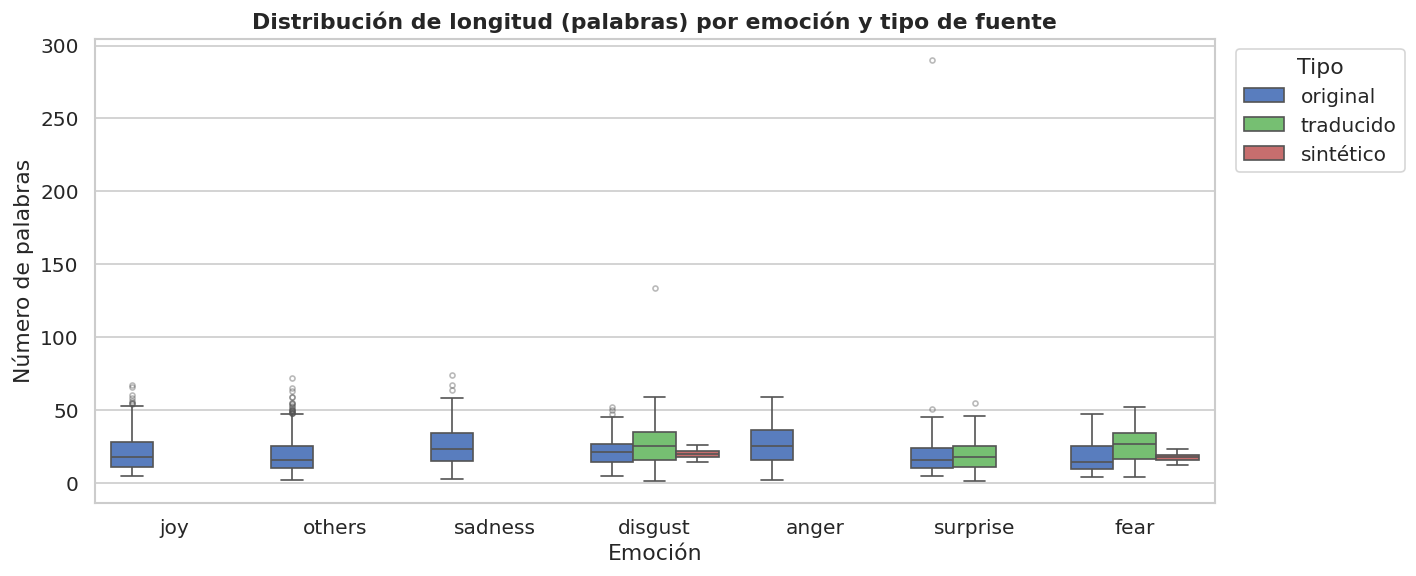

In [50]:
# Boxplot de longitud: original vs traducido vs sintético
order_tipo = ['original', 'traducido', 'sintético']
palette_tipo = {'original': '#4878CF', 'traducido': '#6ACC65', 'sintético': '#D65F5F'}

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=ws_train[ws_train['tipo'].notna()],
            x='emotion', y='n_words', hue='tipo',
            order=EMOTIONS, hue_order=order_tipo,
            palette=palette_tipo,
            flierprops=dict(marker='o', markersize=3, alpha=0.4),
            ax=ax)
ax.set_title('Distribución de longitud (palabras) por emoción y tipo de fuente', fontweight='bold')
ax.set_xlabel('Emoción')
ax.set_ylabel('Número de palabras')
ax.legend(title='Tipo', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(DATA_ROOT / 'figures/length_boxplot_by_source.png', bbox_inches='tight')
plt.show()

---
## Sección 5 — Verificación de Splits

In [51]:
# No data leakage: ningún tweet en más de un split
# Usamos la columna 'text' como identificador canónico (el id puede ser float en with_synthetic)

def check_leakage(train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame, label: str) -> None:
    sets = {
        'train': set(train['text'].str.strip()),
        'val':   set(val['text'].str.strip()),
        'test':  set(test['text'].str.strip()),
    }
    pairs = [('train', 'val'), ('train', 'test'), ('val', 'test')]
    print(f'\n=== Data leakage check ({label}) ===')
    leakage_found = False
    for a, b in pairs:
        overlap = sets[a] & sets[b]
        status = '✓ OK (0 solapamientos)' if len(overlap) == 0 else f'✗ LEAKAGE: {len(overlap)} tweets duplicados'
        print(f'  {a} ∩ {b}: {status}')
        if overlap:
            leakage_found = True
    if not leakage_found:
        print('  → Sin data leakage detectado.')

check_leakage(ns_train, ns_val, ns_test, 'sin sintéticos')
check_leakage(ws_train, ws_val, ws_test, 'con sintéticos')


=== Data leakage check (sin sintéticos) ===
  train ∩ val: ✓ OK (0 solapamientos)
  train ∩ test: ✓ OK (0 solapamientos)
  val ∩ test: ✓ OK (0 solapamientos)
  → Sin data leakage detectado.

=== Data leakage check (con sintéticos) ===
  train ∩ val: ✓ OK (0 solapamientos)
  train ∩ test: ✓ OK (0 solapamientos)
  val ∩ test: ✓ OK (0 solapamientos)
  → Sin data leakage detectado.


In [52]:
# Los datos sintéticos SOLO están en train
print('=== Presencia de datos sintéticos por split (with_synthetic) ===')
for split_name, df in [('train', ws_train), ('val', ws_val), ('test', ws_test)]:
    n_synt = (df['source'] == 'synthetic').sum()
    status = '✓ OK (0)' if (split_name != 'train' and n_synt == 0) else (
        f'✓ {n_synt} muestras sintéticas' if split_name == 'train'
        else f'✗ ERROR: {n_synt} sintéticos en {split_name}'
    )
    print(f'  {split_name:6s}: {status}')

=== Presencia de datos sintéticos por split (with_synthetic) ===
  train : ✓ 90 muestras sintéticas
  val   : ✓ OK (0)
  test  : ✓ OK (0)


In [53]:
# Distribución de clases por split — ambas versiones
def split_distribution(splits: dict, label: str) -> pd.DataFrame:
    rows = {}
    for split_name, df in splits.items():
        counts = df['emotion'].value_counts().reindex(EMOTIONS, fill_value=0)
        rows[split_name] = counts
    return pd.DataFrame(rows)

ns_dist = split_distribution({'train': ns_train, 'val': ns_val, 'test': ns_test}, 'sin_sint')
ws_dist = split_distribution({'train': ws_train, 'val': ws_val, 'test': ws_test}, 'con_sint')

print('=== Distribución de clases por split — SIN sintéticos ===')
display(ns_dist.style.background_gradient(cmap='Blues', axis=None))

print('\n=== Distribución de clases por split — CON sintéticos ===')
display(ws_dist.style.background_gradient(cmap='Greens', axis=None))

=== Distribución de clases por split — SIN sintéticos ===


,train,val,test
emotion,,,
joy,1270,273,272
others,1260,270,270
sadness,706,151,151
disgust,648,139,139
anger,599,128,129
surprise,405,87,87
fear,173,37,37



=== Distribución de clases por split — CON sintéticos ===


,train,val,test
emotion,,,
joy,1270,273,272
others,1260,270,270
sadness,706,151,151
disgust,688,139,139
anger,599,128,129
surprise,405,87,87
fear,223,37,37


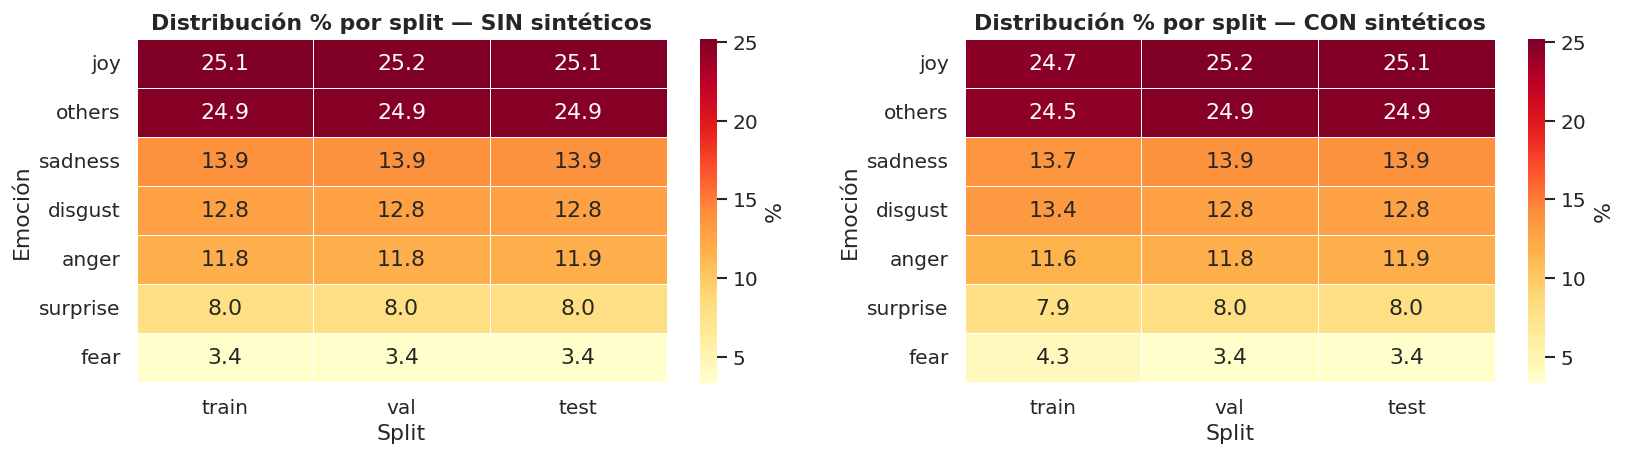

In [54]:
# Heatmap de distribución porcentual por split
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, dist, title in zip(axes,
                            [ns_dist, ws_dist],
                            ['SIN sintéticos', 'CON sintéticos']):
    pct = dist.div(dist.sum(axis=0), axis=1) * 100
    sns.heatmap(pct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': '%'})
    ax.set_title(f'Distribución % por split — {title}', fontweight='bold')
    ax.set_ylabel('Emoción')
    ax.set_xlabel('Split')

plt.tight_layout()
plt.savefig(DATA_ROOT / 'figures/split_distribution_heatmap.png', bbox_inches='tight')
plt.show()

---
## Sección 6 — Decisión Final: ¿Qué versión usar para el fine-tuning?

### Recomendación

**Usar `data/processed/no_synthetic/` para el fine-tuning + class weights.**

**Justificación:**
1. **Calidad sobre cantidad:** Los 50 sintéticos de fear presentan artefactos
   (prefijos numéricos, comillas, duplicados cuasi-idénticos) que introducen
   ruido en el entrenamiento.
2. **Class weights compensa el desequilibrio:** Con `class_weight='balanced'`
   el Trainer ajusta la función de pérdida automáticamente según la frecuencia
   de cada clase, sin necesidad de datos adicionales.
3. **Datos reales en todo el pipeline:** Train, val y test contienen únicamente
   muestras originales y traducidas, todas con etiquetas validadas por humanos.
4. **Los sintéticos se conservan** en `data/processed/with_synthetic/` como
   evidencia de que se exploró esta opción y se descartó por calidad insuficiente.

**Si tras el fine-tuning F1_fear < 0.40:** Reconsiderar generación sintética
con prompt mejorado (eliminar prefijos, generar en batches más pequeños,
validar manualmente antes de incluir).